# Clasificación de sentimiento en reseñas de Steam con RNN y LSTM

En este notebook se entrena y compara un modelo **RNN simple** y un modelo **LSTM**
para clasificar reseñas de videojuegos de Steam en sentimiento **positivo** (recomendado)
o **negativo** (no recomendado).

El dataset proviene de Kaggle: *Sentiment Analysis for Steam Reviews* y se asume que
el archivo CSV se encuentra en:

../data/steam/train.csv


In [2]:
# Celda 2: Imports y configuración general

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import pickle
import json


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Se asume que el notebook está en la carpeta 'notebooks'.
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data" / "steam"
CSV_PATH = DATA_DIR / "train.csv"

print("Versión de TensorFlow:", tf.__version__)
print("Eager execution activo:", tf.executing_eagerly())
print("CSV_PATH:", CSV_PATH)


Versión de TensorFlow: 2.20.0
Eager execution activo: True
CSV_PATH: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\data\steam\train.csv


In [3]:
# Celda 3: Carga del dataset de Steam y selección de columnas

# El archivo CSV debe existir en la ruta indicada.
assert CSV_PATH.exists(), f"No se encontró el archivo: {CSV_PATH}"

df = pd.read_csv(CSV_PATH)

print("Columnas disponibles en el dataset:")
print(df.columns)

# Se ajustan estos nombres si el CSV usa otros.
TEXT_COL = "user_review"
LABEL_COL = "user_suggestion"

# Se seleccionan solo las columnas relevantes y se eliminan filas con NaN.
df = df[[TEXT_COL, LABEL_COL]].dropna()

print("\nNúmero total de reseñas después de limpiar NaN:", len(df))

# Se asegura que la etiqueta sea 0 o 1.
df[LABEL_COL] = df[LABEL_COL].astype(int)

df.head()


Columnas disponibles en el dataset:
Index(['review_id', 'title', 'year', 'user_review', 'user_suggestion'], dtype='object')

Número total de reseñas después de limpiar NaN: 17494


,user_review,user_suggestion
0,I'm scared and hearing creepy voices. So I'll...,1
1,"Best game, more better than Sam Pepper's YouTu...",1
2,"A littly iffy on the controls, but once you kn...",1
3,"Great game, fun and colorful and all that.A si...",1
4,Not many games have the cute tag right next to...,1


Distribución de etiquetas (0 = negativo, 1 = positivo):
Etiqueta 0: 7526 reseñas (43.02 %)
Etiqueta 1: 9968 reseñas (56.98 %)


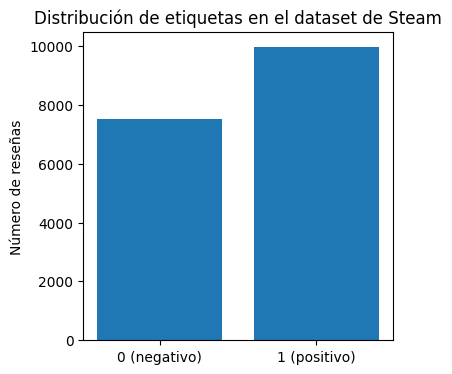

In [4]:
# Celda 4: Distribución de etiquetas (positivo/negativo)

label_counts = df[LABEL_COL].value_counts().sort_index()
total = len(df)

print("Distribución de etiquetas (0 = negativo, 1 = positivo):")
for label, count in label_counts.items():
    pct = 100.0 * count / total
    print(f"Etiqueta {label}: {count} reseñas ({pct:.2f} %)")

plt.figure(figsize=(4, 4))
plt.bar(["0 (negativo)", "1 (positivo)"], label_counts.values)
plt.title("Distribución de etiquetas en el dataset de Steam")
plt.ylabel("Número de reseñas")
plt.show()


In [5]:
# Celda 5: Muestra de reseñas de ejemplo

print("Ejemplos de reseñas de Steam:\n")

for idx in range(5):
    row = df.iloc[idx]
    texto = row[TEXT_COL]
    label = row[LABEL_COL]
    etiqueta_str = "positivo (1)" if label == 1 else "negativo (0)"
    print(f"--- Reseña {idx+1} ({etiqueta_str}) ---")
    print(texto)
    print()


Ejemplos de reseñas de Steam:

--- Reseña 1 (positivo (1)) ---
I'm scared and hearing creepy voices.  So I'll pause for a moment and write a review while I wait for my heart beat to return to atleast somewhat calmer times.  This game is adorable and creepy like my happy tree friends but with the graphics sceme of my childhood (but more bubble and 'clean').  Hello 1990's.What charactes there are (that isnot trying to kill me) were likable and a bit odd.  I did do a few noob things though, such as:Oh look a class room full of ghosts from dead children, lets shine my flashlight on them and stand there staring at them..Or, hmm creepy music, I'll turn around and see if I can see what's chasing me.Never before in a game have I been this afraid of finding a locked door.

--- Reseña 2 (positivo (1)) ---
Best game, more better than Sam Pepper's YouTube account. 10/10What you'll need to play:A computerSome extra pants.Pros:Scary as hell.Fun.Adventure.Spooky.Did I forgot to mention that its scary

In [6]:
# Celda 6: Definición de función de limpieza básica de texto

def clean_text(text: str) -> str:
    """
    Realiza una limpieza básica del texto:
    - Convierte a minúsculas.
    - Elimina URLs.
    - Elimina caracteres no alfabéticos principales.
    - Reemplaza múltiples espacios por uno.
    """
    if not isinstance(text, str):
        text = str(text)
    
    text = text.lower()
    # Se eliminan URLs.
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    # Se eliminan números y caracteres que no sean letras, puntuación básica o espacio.
    text = re.sub(r"[^a-záéíóúüñ.,!?;:()'\" ]", " ", text)
    # Se reemplazan múltiples espacios por uno solo.
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Se aplica limpieza a toda la columna de texto.
df["clean_text"] = df[TEXT_COL].apply(clean_text)

df[["clean_text", LABEL_COL]].head()


,clean_text,user_suggestion
0,i'm scared and hearing creepy voices. so i'll ...,1
1,"best game, more better than sam pepper's youtu...",1
2,"a littly iffy on the controls, but once you kn...",1
3,"great game, fun and colorful and all that.a si...",1
4,not many games have the cute tag right next to...,1


In [7]:
# Celda 7: División en subconjuntos de entrenamiento, validación y prueba

X = df["clean_text"].values
y = df[LABEL_COL].values

# Primero se separa Train+Val de Test.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Luego se separan Train y Val a partir de X_temp.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)
# 0.1765 ≈ 0.15 / 0.85 → resulta en ~70% train, 15% val, 15% test.

print("Tamaños de los subconjuntos:")
print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))


Tamaños de los subconjuntos:
Train: 12244
Val  : 2625
Test : 2625


In [8]:
# Celda 8: Tokenización y construcción del vocabulario

MAX_NUM_WORDS = 30000   # tamaño máximo del vocabulario
MAX_SEQUENCE_LENGTH = 200  # longitud máxima en tokens

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
vocab_size_real = min(MAX_NUM_WORDS, len(word_index) + 1)

print("Tamaño total del vocabulario encontrado:", len(word_index))
print("Tamaño efectivo usado (limitado por MAX_NUM_WORDS):", vocab_size_real)

# Se convierten textos a secuencias de índices.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Se aplica padding para que todas las secuencias tengan la misma longitud.
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

print("Shape X_train_pad:", X_train_pad.shape)
print("Shape X_val_pad  :", X_val_pad.shape)
print("Shape X_test_pad :", X_test_pad.shape)


Tamaño total del vocabulario encontrado: 40669
Tamaño efectivo usado (limitado por MAX_NUM_WORDS): 30000
Shape X_train_pad: (12244, 200)
Shape X_val_pad  : (2625, 200)
Shape X_test_pad : (2625, 200)


In [9]:
# Celda RNN 9: Definición del modelo RNN simple

def build_simple_rnn_model(
    vocab_size: int,
    embedding_dim: int = 128,
    rnn_units: int = 64,
    max_sequence_length: int = 200
) -> tf.keras.Model:
    """
    Define una arquitectura de red RNN simple para clasificación binaria:
    - Capa Embedding.
    - Capa SimpleRNN.
    - Capa densa de salida con activación sigmoide.
    Se fuerza el build del modelo para que aparezcan los parámetros en el summary.
    """
    model = models.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_sequence_length
        ),
        layers.SimpleRNN(rnn_units),
        layers.Dense(1, activation="sigmoid")
    ])
    
    # Se fuerza el "build" para inicializar parámetros y ver el summary.
    model.build(input_shape=(None, max_sequence_length))
    return model

rnn_model_demo = build_simple_rnn_model(
    vocab_size=vocab_size_real,
    embedding_dim=128,
    rnn_units=64,
    max_sequence_length=MAX_SEQUENCE_LENGTH  # usa el mismo MAX_SEQUENCE_LENGTH que definiste (200)
)

rnn_model_demo.summary()


c:\Users\DANIELA\Documents\proyecto_final_procesamiento\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,852,417 (14.70 MB)

 Trainable params: 3,852,417 (14.70 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Celda: Función de entrenamiento genérica para texto (RNN y LSTM)
from tensorflow.keras.callbacks import EarlyStopping

def train_text_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs,
    lr,
    batch_size=64,
    title_prefix="Modelo",
    use_early_stopping=False,
    patience=2
):
    """
    Esta función entrena un modelo de texto (RNN o LSTM) y genera las curvas de
    pérdida y exactitud.

    - Si 'use_early_stopping' es False, el entrenamiento siempre recorre todas
      las épocas indicadas.
    - Si 'use_early_stopping' es True, se usa EarlyStopping con la paciencia dada.
    """

    # Se define una función de pérdida con un ligero label smoothing para ayudar a generalizar.
    loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=["accuracy"],
        # Se deja el modo por defecto (no run_eagerly) para que el entrenamiento sea más estable.
    )

    callbacks = []
    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True
        )
        callbacks.append(early_stop)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,  # si la lista está vacía, no se usa EarlyStopping
        verbose=1
    )

    # Se extraen las curvas de entrenamiento.
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss_hist = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    # Se grafican exactitud y pérdida.
    plt.figure(figsize=(12, 5))

    # Exactitud
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.xlabel("Época")
    plt.ylabel("Exactitud")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()

    # Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss_hist, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

    return history



=== Entrenando RNN A (emb128, units64, lr=1e-3) ===
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5632 - loss: 0.6867 - val_accuracy: 0.5726 - val_loss: 0.6824
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6288 - loss: 0.6465 - val_accuracy: 0.5707 - val_loss: 0.6997
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6572 - loss: 0.5909 - val_accuracy: 0.5730 - val_loss: 0.7106
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6492 - loss: 0.5838 - val_accuracy: 0.5768 - val_loss: 0.7191
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6653 - loss: 0.5716 - val_accuracy: 0.5832 - val_loss: 0.7175
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6650 - loss: 0.5714 - val_accuracy: 0.5802 - val_loss: 0.7330
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6570 - loss: 0.5853 - val_accuracy: 0.5726 - val_loss: 0.7594
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 

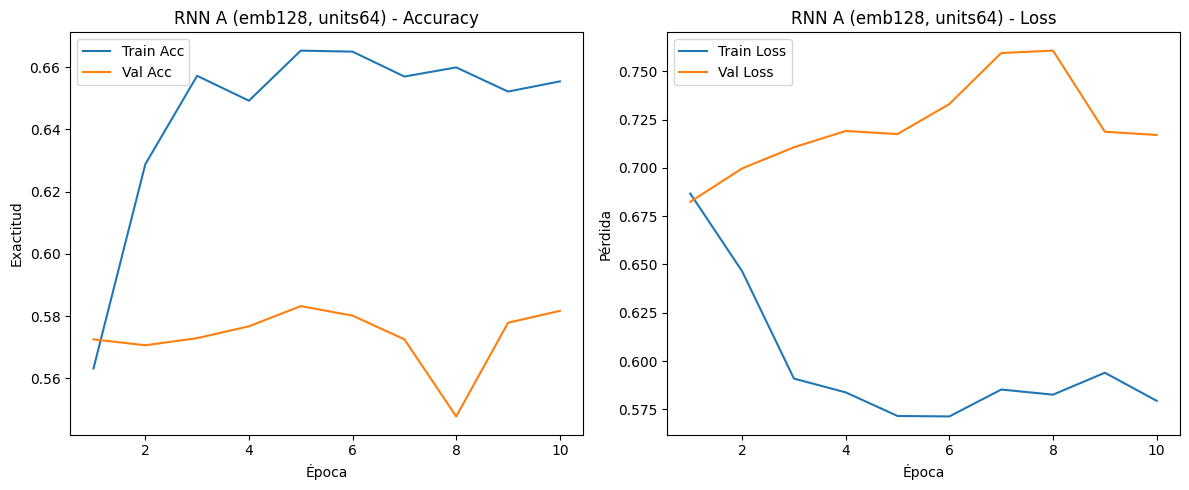


=== Entrenando RNN B (emb64, units64, lr=5e-4) ===
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5652 - loss: 0.6860 - val_accuracy: 0.5714 - val_loss: 0.6828
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6179 - loss: 0.6630 - val_accuracy: 0.5684 - val_loss: 0.6891
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6437 - loss: 0.6312 - val_accuracy: 0.5745 - val_loss: 0.6905
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6507 - loss: 0.6077 - val_accuracy: 0.5764 - val_loss: 0.6964
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6590 - loss: 0.5958 - val_accuracy: 0.5737 - val_loss: 0.7014
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6811 - loss: 0.5666 - val_accuracy: 0.5505 - val_loss: 0.7069
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6577 - loss: 0.6042 - val_accuracy: 0.5714 - val_loss: 0.7085
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27

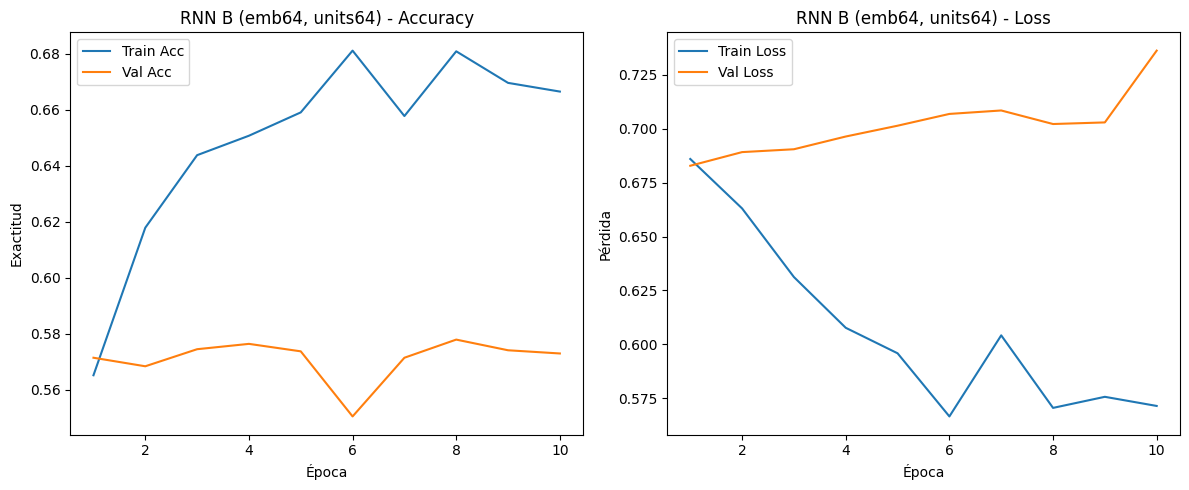

In [11]:
# Celda RNN 11: Entrenamiento del modelo RNN con dos configuraciones

rnn_results = {}

# Configuración RNN A: emb=128, units=64, lr=1e-3
print("\n=== Entrenando RNN A (emb128, units64, lr=1e-3) ===")
rnn_model_A = build_simple_rnn_model(
    vocab_size=vocab_size_real,
    embedding_dim=128,
    rnn_units=64,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)
history_rnn_A = train_text_model(
    rnn_model_A,
    X_train_pad, y_train,
    X_val_pad, y_val,
    epochs=10,
    lr=1e-3,
    batch_size=64,
    title_prefix="RNN A (emb128, units64)"
)
rnn_results["RNN_A"] = {
    "model": rnn_model_A,
    "history": history_rnn_A
}

# Configuración RNN B: emb=64, units=64, lr=5e-4 (un poco distinta)
print("\n=== Entrenando RNN B (emb64, units64, lr=5e-4) ===")
rnn_model_B = build_simple_rnn_model(
    vocab_size=vocab_size_real,
    embedding_dim=64,
    rnn_units=64,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)
history_rnn_B = train_text_model(
    rnn_model_B,
    X_train_pad, y_train,
    X_val_pad, y_val,
    epochs=10,
    lr=5e-4,
    batch_size=64,
    title_prefix="RNN B (emb64, units64)"
)
rnn_results["RNN_B"] = {
    "model": rnn_model_B,
    "history": history_rnn_B
}


In [12]:
# Celda 12: LSTM con más capacidad y dropout

def build_lstm_model(vocab_size: int,
                     embedding_dim: int = 128,
                     lstm_units: int = 128,
                     max_sequence_length: int = 200) -> tf.keras.Model:
    """
    Define una LSTM más grande con dropout para manejar mejor textos largos.
    """
    model = models.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_sequence_length
        ),
        layers.LSTM(
            lstm_units,
            dropout=0.3,           # apaga neuronas en la entrada de la LSTM
            recurrent_dropout=0.3  # apaga conexiones recurrentes (solo CPU)
        ),
        layers.Dense(1, activation="sigmoid")
    ])
    
    # Se fuerza el build para ver los parámetros en el summary
    model.build(input_shape=(None, max_sequence_length))
    return model

lstm_model = build_lstm_model(
    vocab_size=vocab_size_real,
    embedding_dim=128,
    lstm_units=128,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)

lstm_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,971,713 (15.15 MB)

 Trainable params: 3,971,713 (15.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - accuracy: 0.5692 - loss: 0.6850 - val_accuracy: 0.5699 - val_loss: 0.6819
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.5770 - loss: 0.6819 - val_accuracy: 0.5779 - val_loss: 0.6813
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.6025 - loss: 0.6721 - val_accuracy: 0.5775 - val_loss: 0.6801
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.6154 - loss: 0.6463 - val_accuracy: 0.5905 - val_loss: 0.6837
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.6339 - loss: 0.6184 - val_accuracy: 0.5931 - val_loss: 0.6944


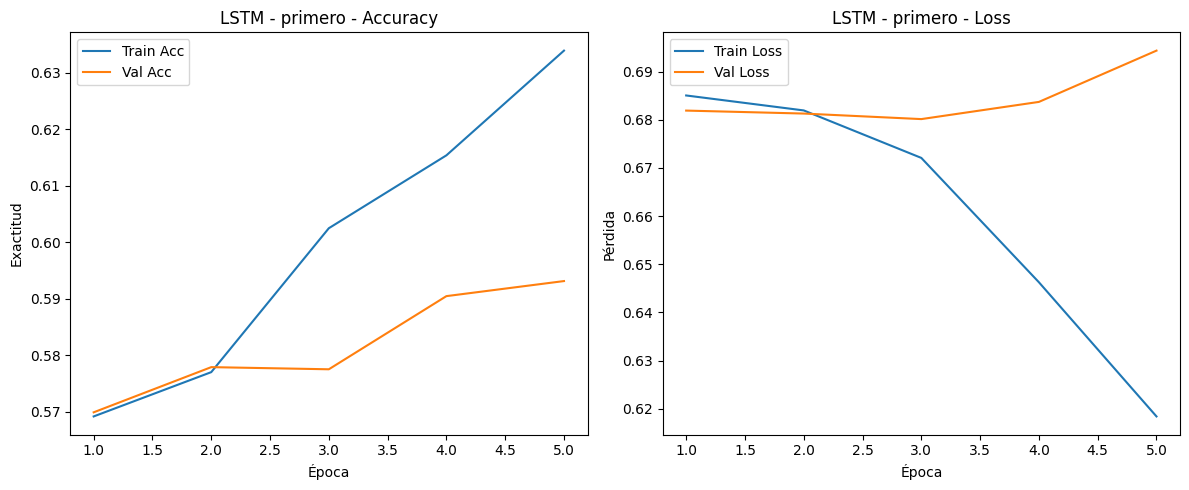

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 50s 251ms/step - accuracy: 0.5653 - loss: 0.6858 - val_accuracy: 0.5699 - val_loss: 0.6816
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 235ms/step - accuracy: 0.5697 - loss: 0.6839 - val_accuracy: 0.5699 - val_loss: 0.6816
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 235ms/step - accuracy: 0.5699 - loss: 0.6835 - val_accuracy: 0.5699 - val_loss: 0.6817
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 234ms/step - accuracy: 0.5701 - loss: 0.6830 - val_accuracy: 0.5699 - val_loss: 0.6816
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 234ms/step - accuracy: 0.5712 - loss: 0.6818 - val_accuracy: 0.5707 - val_loss: 0.6814
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 46s 241ms/step - accuracy: 0.5757 - loss: 0.6800 - val_accuracy: 0.5710 - val_loss: 0.6809
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 234ms/step - accuracy: 0.5867 - loss: 0.6761 - val_accuracy: 0.5890 - val_loss: 0.6784
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 46s 242ms/step - accuracy: 0.6052 - loss: 0

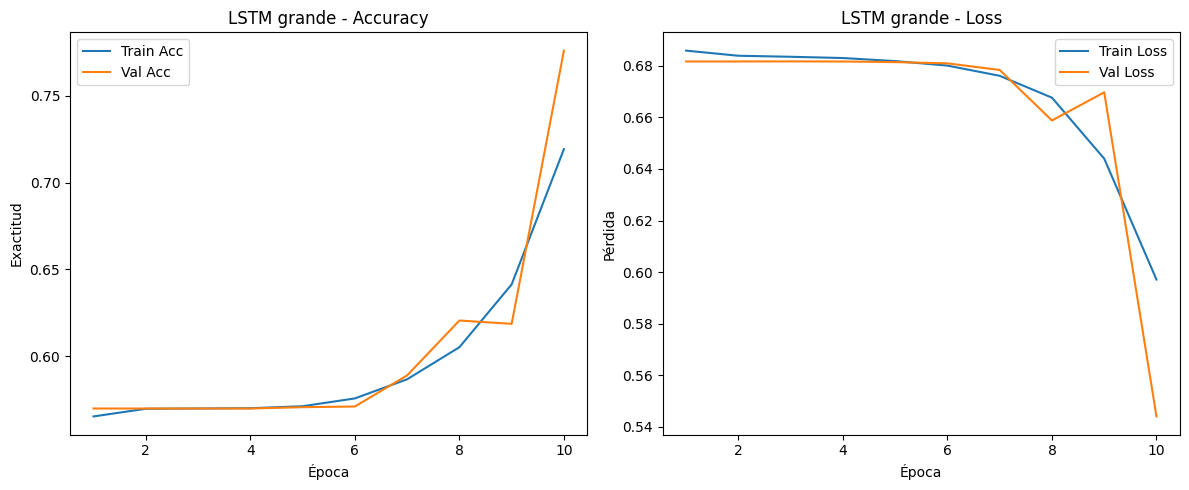

In [13]:
# Celda 13: Entrenamiento del modelo LSTM 

# Configuración LSTM 1: emb64, units64, lr=1e-3
lstm_model_1 = build_lstm_model(
    vocab_size=vocab_size_real,
    embedding_dim=64,
    lstm_units=64,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)
history_lstm_1 = train_text_model(
    lstm_model_1,
    X_train_pad, y_train,
    X_val_pad, y_val,
    epochs=5,
    lr=1e-3,
    title_prefix="LSTM - primero",
    use_early_stopping=False       
)

# Configuración LSTM 2: emb128, units128, lr=1e-4 (más capacidad)
lstm_model_2 = build_lstm_model(
    vocab_size=vocab_size_real,
    embedding_dim=128,
    lstm_units=128,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)
history_lstm_2 = train_text_model(
    lstm_model_2,
    X_train_pad, y_train,
    X_val_pad, y_val,
    epochs=10,
    lr=1e-4,
    title_prefix="LSTM grande",
    use_early_stopping=False       
)


In [17]:
# comparación de LSTM 1 vs LSTM 2

def best_val_acc(history):
    """Obtiene la mejor exactitud de validación alcanzada por un entrenamiento."""
    return max(history.history["val_accuracy"])

acc_lstm_1 = best_val_acc(history_lstm_1)
acc_lstm_2 = best_val_acc(history_lstm_2)

print(f"Mejor val_accuracy LSTM 1 (emb64, units64):   {acc_lstm_1:.4f}")
print(f"Mejor val_accuracy LSTM 2 (emb128, units128): {acc_lstm_2:.4f}")

if acc_lstm_2 >= acc_lstm_1:
    print("\nLa mejor configuración es LSTM 2 (LSTM grande).")
else:
    print("\nLa mejor configuración es LSTM 1 (LSTM primero).")


Mejor val_accuracy LSTM 1 (emb64, units64):   0.5931
Mejor val_accuracy LSTM 2 (emb128, units128): 0.7760

La mejor configuración es LSTM 2 (LSTM grande).


In [26]:
# Celda 13: Comparación de LSTM 1 vs LSTM 2 en validación y prueba

def best_val_acc(history):
    """
    Obtiene la mejor exactitud de validación alcanzada durante el entrenamiento
    de un modelo.
    """
    return max(history.history["val_accuracy"])

# La mejor val_accuracy alcanzada por cada modelo durante su entrenamiento.
val_acc_lstm_1 = best_val_acc(history_lstm_1)
val_acc_lstm_2 = best_val_acc(history_lstm_2)

print(f"Mejor val_accuracy LSTM 1: {val_acc_lstm_1:.4f}")
print(f"Mejor val_accuracy LSTM 2: {val_acc_lstm_2:.4f}")

# Evaluación en el conjunto de prueba para cada modelo entrenado.
test_loss_1, test_acc_1 = lstm_model_1.evaluate(X_test_pad, y_test, verbose=0)
test_loss_2, test_acc_2 = lstm_model_2.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nLSTM 1 - Test Loss: {test_loss_1:.4f} | Test Accuracy: {test_acc_1:.4f}")
print(f"LSTM 2 - Test Loss: {test_loss_2:.4f} | Test Accuracy: {test_acc_2:.4f}")

# Selección automática del mejor modelo según el accuracy en test.
if test_acc_2 >= test_acc_1:
    print("\nLa mejor configuración es LSTM 2 (lstm_model_2).")
    best_lstm = lstm_model_2
    BEST_MODEL_TYPE = "LSTM"
    BEST_CONFIG_NAME = "LSTM_2 (emb128, units128, lr=..., epochs=...)"
    BEST_TEST_ACC = test_acc_2
else:
    print("\nLa mejor configuración es LSTM 1 (lstm_model_1).")
    best_lstm = lstm_model_1
    BEST_MODEL_TYPE = "LSTM"
    BEST_CONFIG_NAME = "LSTM_1 (emb64, units64, lr=..., epochs=...)"
    BEST_TEST_ACC = test_acc_1

print(f"\nModelo final elegido: {BEST_MODEL_TYPE} - {BEST_CONFIG_NAME}")
print(f"Accuracy final en TEST del modelo elegido: {BEST_TEST_ACC:.4f}")


Mejor val_accuracy LSTM 1: 0.5931
Mejor val_accuracy LSTM 2: 0.7760

LSTM 1 - Test Loss: 0.7061 | Test Accuracy: 0.5749
LSTM 2 - Test Loss: 0.5556 | Test Accuracy: 0.7653

La mejor configuración es LSTM 2 (lstm_model_2).

Modelo final elegido: LSTM - LSTM_2 (emb128, units128, lr=..., epochs=...)
Accuracy final en TEST del modelo elegido: 0.7653


Test Loss: 0.5556
Test Accuracy: 0.7653
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

Reporte de clasificación (0 = negativo, 1 = positivo):
              precision    recall  f1-score   support

    negativo       0.76      0.66      0.71      1129
    positivo       0.77      0.84      0.80      1496

    accuracy                           0.77      2625
   macro avg       0.76      0.75      0.76      2625
weighted avg       0.76      0.77      0.76      2625



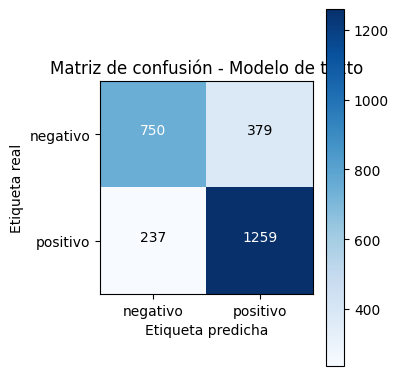

In [27]:
# Celda 15: Evaluación en el conjunto de prueba y matriz de confusión
# Esta celda evalúa el modelo final de texto (best_lstm) en el conjunto de prueba
# y genera la matriz de confusión y el reporte de clasificación.

from sklearn.metrics import confusion_matrix, classification_report

# Evaluación numérica del modelo final en el conjunto de prueba.
test_loss, test_acc = best_lstm.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predicciones de probabilidad para cada ejemplo de prueba.
y_prob = best_lstm.predict(X_test_pad)
# Se umbraliza en 0.5 para obtener etiquetas predichas 0/1.
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Cálculo de la matriz de confusión.
cm = confusion_matrix(y_test, y_pred)

print("\nReporte de clasificación (0 = negativo, 1 = positivo):")
print(classification_report(y_test, y_pred, target_names=["negativo", "positivo"]))

# Visualización de la matriz de confusión.
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matriz de confusión - Modelo de texto")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["negativo", "positivo"])
plt.yticks(tick_marks, ["negativo", "positivo"])

# Se escribe el valor de cada celda sobre el recuadro correspondiente.
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.tight_layout()
plt.show()


In [28]:
# Celda 16: Guardado del modelo final de texto, tokenizer y mapa de etiquetas

# Se asegura que exista la carpeta 'modelos' en la raíz del proyecto.
MODELS_DIR = BASE_DIR / "modelos"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 1) Modelo LSTM final
# En este proyecto se utiliza la LSTM como modelo de texto final, por lo que se guarda
# el objeto 'best_lstm' entrenado previamente en el archivo 'lstm_steam.h5'.
text_model_path = MODELS_DIR / "lstm_steam.h5"
best_lstm.save(text_model_path)
print(f"Modelo de texto final guardado en: {text_model_path}")

# 2) Tokenizer
# Se guarda el tokenizer de Keras usado para convertir texto a secuencias, de forma
# que la aplicación web pueda reproducir exactamente el mismo preprocesamiento.
tokenizer_path = MODELS_DIR / "tokenizer_steam.pkl"
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer guardado en: {tokenizer_path}")

# 3) Mapa de etiquetas
# Se define un diccionario simple que indica qué significa cada etiqueta numérica.
label_map = {
    "0": "negativo (no recomendado)",
    "1": "positivo (recomendado)"
}
label_map_path = MODELS_DIR / "label_map_steam.json"
with open(label_map_path, "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)
print(f"Mapa de etiquetas guardado en: {label_map_path}")


Modelo de texto final guardado en: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\modelos\lstm_steam.h5
Tokenizer guardado en: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\modelos\tokenizer_steam.pkl
Mapa de etiquetas guardado en: C:\Users\DANIELA\Documents\proyecto_final_procesamiento\modelos\label_map_steam.json


In [29]:
# Celda 17: Prueba de inferencia sobre textos de ejemplo
# En esta celda se verifica que el modelo final (best_lstm) y el tokenizer
# funcionan correctamente sobre algunos textos nuevos.

ejemplos = [
    "This game is amazing, I really enjoyed the story and the gameplay.",
    "The game is full of bugs and crashes all the time. Not recommended."
]

# Se aplica la misma limpieza utilizada en el preprocesamiento del dataset.
ejemplos_clean = [clean_text(t) for t in ejemplos]

# Se convierten los textos limpios a secuencias de índices usando el tokenizer entrenado.
ejemplos_seq = tokenizer.texts_to_sequences(ejemplos_clean)

# Se aplica padding para que todas las secuencias tengan la misma longitud
# que las usadas durante el entrenamiento (MAX_SEQUENCE_LENGTH).
ejemplos_pad = pad_sequences(
    ejemplos_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

# Se obtienen las probabilidades predichas por el modelo final de texto.
prob = best_lstm.predict(ejemplos_pad).ravel()

# Se umbraliza en 0.5 para decidir si la reseña es positiva (1) o negativa (0).
pred = (prob >= 0.5).astype(int)

for txt, p, pr in zip(ejemplos, pred, prob):
    etiqueta = "positivo" if p == 1 else "negativo"
    print("Texto:", txt)
    print(f"Predicción: {etiqueta} (prob={pr:.3f})")
    print()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Texto: This game is amazing, I really enjoyed the story and the gameplay.
Predicción: positivo (prob=0.745)

Texto: The game is full of bugs and crashes all the time. Not recommended.
Predicción: positivo (prob=0.745)



In [30]:
# Celda extra: probar el modelo con reseñas reales del dataset

# Se toman 3 reseñas positivas y 3 negativas al azar
ejemplos_df = pd.concat([
    df[df[LABEL_COL] == 1].sample(3, random_state=1),
    df[df[LABEL_COL] == 0].sample(3, random_state=2)
])

for idx, row in ejemplos_df.iterrows():
    txt = row[TEXT_COL]
    real = row[LABEL_COL]  # 0 o 1
    
    # Mismo preprocesamiento que antes
    txt_clean = clean_text(txt)
    seq = tokenizer.texts_to_sequences([txt_clean])
    pad = pad_sequences(
        seq,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )
    
    prob = best_lstm.predict(pad).ravel()[0]
    pred = 1 if prob >= 0.5 else 0
    
    etiqueta_real = "positivo" if real == 1 else "negativo"
    etiqueta_pred = "positivo" if pred == 1 else "negativo"
    
    print("=== Ejemplo ===")
    print("Texto:", txt[:200], "...")
    print("Etiqueta real      :", etiqueta_real)
    print(f"Predicción modelo  : {etiqueta_pred} (prob={prob:.3f})")
    print()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
=== Ejemplo ===
Texto: Early Access ReviewThis is an edit of my last review (which discussed lack of graphics settings). Turns out I was wrong! In order to change graphics settings, you just hop into a game press Esc and bo ...
Etiqueta real      : positivo
Predicción modelo  : positivo (prob=0.745)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
=== Ejemplo ===
Texto: if you say this is bad then you stink bc this is a fun game. you see its fun with freinds but not bots. and if you actually like the game you will have freinds but if you dont like it, thats why you h ...
Etiqueta real      : positivo
Predicción modelo  : positivo (prob=0.745)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
=== Ejemplo ===
Texto: Have a special someone who isn't into video games? Maybe a FWB that doesn't understand the special addiction we all share? Introduce this game to them, like yesterday. It will begin their slow spiral  ...
Etiqueta real      : positivo
Predicción modelo  : neg